<a href="https://colab.research.google.com/github/ryunseo10/10th-ML/blob/week_5/Week5_%EC%98%88%EC%8A%B5%EA%B3%BC%EC%A0%9C(1)_%EC%9D%B4%EB%A5%9C%EC%84%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Decision tree and random forest classifeir models

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# Data Review

In [14]:
data = pd.read_csv("/content/drug200.csv")

data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [15]:
#데이터의 정보
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [9]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [12]:
# data.corr() : 데이터끼리의 상관관계 알아보기 -> 숫자만 가능. 문자 X

data.corr(numeric_only=True)

,Age,Na_to_K
Age,1.000000,-0.063119
Na_to_K,-0.063119,1.000000


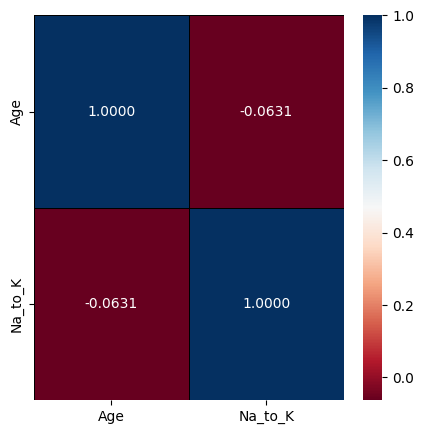

In [18]:
f, ax = plt.subplots(figsize = (5,5))
sns.heatmap(data.corr(numeric_only=True), annot = True, linewidths=0.5, linecolor = "black", fmt = ".4f",cmap = "RdBu", ax = ax)
plt.show()

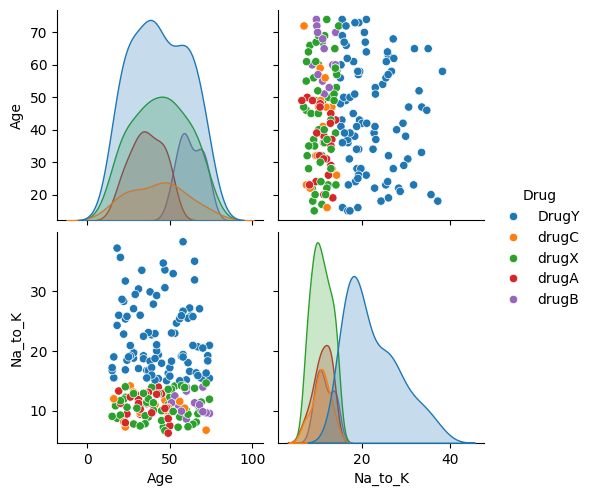

In [20]:
# Visualization of correlation results with seaborn library pairplot
#피처들 상관관계를 그림으로 표현
# 대각선 방향(=자기 자신) : 해당 변수의 값이 어떻게 표현되는지 히스토그램으로 표
# 나머지 칸(=서로 다른 변수) : 두 변수의 관계를 점으로 찍은 산점도로 나타남

sns.pairplot(data, hue = "Drug")

In [21]:
# Dataset columns names
data.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [23]:
# Data in the age column

#dropna = False : NaN이 있어도 함께 셈. 기본값인 True는 NaN는 무시
data["Age"].value_counts(dropna=False)

,count
Age,
47,8
23,7
28,7
49,7
32,6
39,6
50,5
60,5
22,5


****

In [24]:
# Data in the Sex column
data["Sex"].value_counts()

,count
Sex,
M,104
F,96


****

In [25]:
# Data in the BP(Blood Pressure Levels) column
data["BP"].value_counts()

,count
BP,
HIGH,77
LOW,64
NORMAL,59


****

In [26]:
# Data in the Cholesterol column
data["Cholesterol"].value_counts()

,count
Cholesterol,
HIGH,103
NORMAL,97


****

In [27]:
# Data in the Drug column
data["Drug"].value_counts()

,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


# Data Visualization <a id = "2"></a>

In [29]:
# I visualized the number of age in the dataset.
dataAge = data["Age"].value_counts(dropna = False)
npar_dataAge = np.array(dataAge)
x = list(npar_dataAge)
y = data.Age.value_counts().index

DataAge = {"Age": y, "Number": x}
DataAge = pd.DataFrame(DataAge)

# px.bar :  막대그래프 생성. px는 plotly express의 약
fig = px.bar(DataAge, x = "Age", y = "Number")
fig.show()

In [30]:
# I visualized the number of Sex in the dataset.
colors = ['gold', 'mediumturquoise']

# 파이 차트 생
fig = go.Figure(data = [go.Pie(labels= ['M', 'F'], values=[104, 96])])

# 세부 디자인 수정.
fig.update_traces(
    hoverinfo = 'label + percent', # 마우스를 올리면 '이름 + 퍼센트'를 보여줘!
    textinfo = 'value',            # 차트 위에 직접 써줄 글자는 '실제 숫자(104, 96)'로 해줘!
    textfont_size = 20,            # 글자 크기는 큼직하게 20으로!
    marker = dict(
        colors = colors,           # 위에서 정한 금색/민트색 입히기
        line = dict(color = '#000000', width = 2) # 조각 테두리를 검정색(#000000), 두께 2로 둘러줘!
    )
)

fig.show()

In [31]:
# I visualized the number of BP(Blood Pressure Levels) in the dataset.
fig = px.bar(x = ["HIGH", "LOW", "NORMAL"], y = [77, 64, 59])

fig.show()

In [32]:
# I visualized the number of Cholesterol in the dataset.
fig = px.histogram(x = ["HIGH", "NORMAL"], y = [103, 97])
fig.show()

In [33]:
# I visualized the number of Drug in the dataset.
fig = go.Figure(data = [go.Pie(labels=["DrugY","DrugX","DrugA","DrugC","DrugB"], values=[91,54,23,16,16])])

fig.update_traces(hoverinfo = 'label + percent', textinfo = 'value', textfont_size = 20,
                 marker = dict(colors = px.colors.sequential.RdBu, line = dict( color = '#000000', width = 2)))

fig.show()

In [34]:
# I visualized the relationship between age and Na_To_K(Na to Potassium Ration).
fig = px.scatter(data, x = "Na_to_K", y="Age", color="Drug",
                 size='Age', hover_data=['Na_to_K'])
fig.show()

# Classifications Models

## Data Preparing <a id = "cm1"></a>

In [50]:
dataclass = pd.read_csv("/content/drug200.csv")
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [37]:
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [54]:
# Change Age type.
# F = 1
# M = 0
dataclass = pd.read_csv("/content/drug200.csv")
dataclass.Sex = [1 if i == "F" else 0 for i in dataclass.Sex]
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,HIGH,HIGH,25.355,DrugY
1,47,0,LOW,HIGH,13.093,drugC
2,47,0,LOW,HIGH,10.114,drugC
3,28,1,NORMAL,HIGH,7.798,drugX
4,61,1,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,LOW,HIGH,11.567,drugC
196,16,0,LOW,HIGH,12.006,drugC
197,52,0,NORMAL,HIGH,9.894,drugX
198,23,0,NORMAL,NORMAL,14.020,drugX


In [55]:
# Change BP(Blood Pressure Levels) type.
# LOW = 2
# NORMAL = 1
# HIGH = 0

import warnings
warnings.filterwarnings('ignore')

for i in range(0,len(dataclass.BP)):
    if dataclass.BP[i] == "LOW":
        dataclass.BP[i] = 2

    elif dataclass.BP[i] == "NORMAL":
        dataclass.BP[i] = 1

    else:
        dataclass.BP[i] = 0


In [56]:
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,HIGH,25.355,DrugY
1,47,0,2,HIGH,13.093,drugC
2,47,0,2,HIGH,10.114,drugC
3,28,1,1,HIGH,7.798,drugX
4,61,1,2,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,2,HIGH,11.567,drugC
196,16,0,2,HIGH,12.006,drugC
197,52,0,1,HIGH,9.894,drugX
198,23,0,1,NORMAL,14.020,drugX


In [57]:
# Change Cholesterol type.
# HIGH = 1
# NORMAL = 0
dataclass.Cholesterol = [1 if i == "HIGH" else 0 for i in dataclass.Cholesterol]
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,1,25.355,DrugY
1,47,0,2,1,13.093,drugC
2,47,0,2,1,10.114,drugC
3,28,1,1,1,7.798,drugX
4,61,1,2,1,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,2,1,11.567,drugC
196,16,0,2,1,12.006,drugC
197,52,0,1,1,9.894,drugX
198,23,0,1,0,14.020,drugX


In [58]:
# Change Drug type.
# DrugY = 4
# DrugX = 3
# DrugA = 2
# DrugC = 1
# DrugB = 0

import warnings
warnings.filterwarnings('ignore')

for i in range(0,len(dataclass)):
    if dataclass.Drug[i] == "DrugY":
        dataclass.Drug[i] = 4
    elif dataclass.Drug[i] == "drugX":
        dataclass.Drug[i] = 3
    elif dataclass.Drug[i] == "drugA":
        dataclass.Drug[i] = 2
    elif dataclass.Drug[i] == "drugC":
        dataclass.Drug[i] = 1
    else:
        dataclass.Drug[i] = 0

In [59]:
# It is the final form of the dataset.
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,1,25.355,4
1,47,0,2,1,13.093,1
2,47,0,2,1,10.114,1
3,28,1,1,1,7.798,3
4,61,1,2,1,18.043,4
...,...,...,...,...,...,...
195,56,1,2,1,11.567,1
196,16,0,2,1,12.006,1
197,52,0,1,1,9.894,3
198,23,0,1,0,14.020,3


In [60]:
# I check again because possible unchanged types.
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.5+ KB


In [61]:
# I saw don't change two columns of type and I change them to integer types.
data_types_dict = {'BP': int, "Drug": int}

dataclass = dataclass.astype(data_types_dict)

dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


In [62]:
# x_data
x_data = dataclass.drop(["Drug"], axis = 1)

#y_data
y_data = dataclass.Drug.values

In [63]:
x_data

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,1,0,1,25.355
1,47,0,2,1,13.093
2,47,0,2,1,10.114
3,28,1,1,1,7.798
4,61,1,2,1,18.043
...,...,...,...,...,...
195,56,1,2,1,11.567
196,16,0,2,1,12.006
197,52,0,1,1,9.894
198,23,0,1,0,14.020


In [64]:
y_data

array([4, 1, 1, 3, 4, 3, 4, 1, 4, 4, 1, 4, 4, 4, 3, 4, 3, 2, 1, 4, 4, 4,
       4, 4, 4, 4, 4, 3, 4, 4, 3, 0, 3, 4, 3, 3, 2, 3, 3, 3, 4, 0, 4, 3,
       3, 3, 2, 1, 4, 4, 4, 3, 4, 4, 0, 1, 0, 4, 3, 4, 4, 2, 4, 3, 0, 4,
       2, 3, 4, 4, 0, 4, 3, 4, 4, 4, 2, 4, 2, 3, 0, 3, 1, 2, 1, 0, 3, 4,
       4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 2, 2, 1, 3, 4, 3, 3, 4, 0, 4,
       2, 3, 3, 3, 3, 4, 3, 3, 2, 4, 4, 4, 4, 4, 0, 4, 4, 3, 4, 3, 4, 4,
       3, 4, 4, 3, 0, 2, 0, 3, 2, 4, 0, 4, 2, 3, 3, 2, 3, 1, 2, 0, 3, 3,
       4, 1, 2, 4, 1, 3, 3, 0, 3, 4, 4, 4, 4, 3, 4, 2, 3, 3, 4, 4, 2, 4,
       2, 4, 4, 4, 4, 3, 3, 4, 4, 4, 0, 2, 4, 4, 4, 2, 4, 1, 4, 1, 1, 3,
       3, 3])

In [ ]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=1)

## Decision Tree Classifier



In [66]:
from sklearn.model_selection import train_test_split

# 1. 'Drug'는 정답(y), 나머지는 문제(X)로 분리
X = dataclass.drop('Drug', axis=1)
y = dataclass['Drug']

# 2. 데이터를 학습용(80%)과 테스트용(20%)으로 쪼개기
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

dtc = DecisionTreeClassifier()

# Fit the model
dtc.fit(x_train, y_train)

# Predict the x_test
predict = dtc.predict(x_test)

print('The accuracy of the Decision Tree is',metrics.accuracy_score(predict,y_test))

The accuracy of the Decision Tree is 1.0


### Decision Tree Classifier with "gini"

In [68]:
DTC_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)


# Fit the model
DTC_gini.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [69]:
y_pred_gini = DTC_gini.predict(x_test)

In [70]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.8750


In [71]:
y_pred_train_gini = DTC_gini.predict(x_train)

y_pred_train_gini

array([3, 3, 3, 4, 4, 3, 4, 4, 4, 3, 3, 4, 3, 4, 3, 4, 2, 4, 4, 4, 2, 4,
       0, 4, 3, 4, 4, 4, 4, 0, 3, 3, 3, 0, 2, 3, 4, 3, 2, 3, 3, 4, 2, 2,
       2, 0, 0, 2, 4, 2, 4, 4, 2, 4, 4, 4, 3, 4, 3, 4, 4, 3, 0, 3, 4, 2,
       3, 4, 3, 3, 4, 4, 3, 3, 0, 4, 0, 3, 4, 4, 4, 0, 3, 2, 4, 4, 4, 2,
       3, 3, 4, 3, 4, 4, 3, 0, 3, 3, 4, 4, 4, 4, 4, 4, 0, 3, 3, 2, 4, 2,
       2, 3, 4, 4, 4, 4, 3, 4, 2, 3, 4, 4, 3, 4, 3, 0, 4, 4, 3, 3, 4, 4,
       4, 4, 3, 4, 3, 3, 4, 3, 3, 4, 3, 4, 0, 3, 4, 3, 4, 4, 4, 3, 4, 4,
       4, 3, 3, 4, 4, 3])

In [72]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_gini)))

Training-set accuracy score: 0.9313


In [73]:
# Print the scores on training and test set

print('Training set score: {:.4f}'.format(DTC_gini.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(DTC_gini.score(x_test, y_test)))

Training set score: 0.9313
Test set score: 0.8750


### Decision Tree Classifier with "entropy"

In [74]:
# instantiate the DecisionTreeClassifier model with criterion entropy
DTC_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)


# Fit the model
DTC_en.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [75]:
y_pred_en = DTC_en.predict(x_test)

In [76]:
print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy: 0.8750


In [77]:
y_pred_train_en = DTC_en.predict(x_train)

y_pred_train_en

array([3, 3, 3, 4, 4, 3, 4, 4, 4, 3, 3, 4, 3, 4, 3, 4, 2, 4, 4, 4, 2, 4,
       0, 4, 3, 4, 4, 4, 4, 0, 3, 3, 3, 0, 2, 3, 4, 3, 2, 3, 3, 4, 2, 2,
       2, 0, 0, 2, 4, 2, 4, 4, 2, 4, 4, 4, 3, 4, 3, 4, 4, 3, 0, 3, 4, 2,
       3, 4, 3, 3, 4, 4, 3, 3, 0, 4, 0, 3, 4, 4, 4, 0, 3, 2, 4, 4, 4, 2,
       3, 3, 4, 3, 4, 4, 3, 0, 3, 3, 4, 4, 4, 4, 4, 4, 0, 3, 3, 2, 4, 2,
       2, 3, 4, 4, 4, 4, 3, 4, 2, 3, 4, 4, 3, 4, 3, 0, 4, 4, 3, 3, 4, 4,
       4, 4, 3, 4, 3, 3, 4, 3, 3, 4, 3, 4, 0, 3, 4, 3, 4, 4, 4, 3, 4, 4,
       4, 3, 3, 4, 4, 3])

In [79]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 0.9313


In [80]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(DTC_en.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(DTC_en.score(x_test, y_test)))

Training set score: 0.9313
Test set score: 0.8750


## Random Forest Classifier

In [81]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state = 0)

# Fit the model
rfc.fit(x_train, y_train)

# Predict the model
predict = rfc.predict(x_test)

print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 1.0


### Random Forest Classifier with "n_estimators=100"

In [82]:
from sklearn.ensemble import RandomForestClassifier

rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)

# Fit the model
rfc_100.fit(x_train, y_train)

# Predict the model
predict = rfc_100.predict(x_test)

print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 1.0


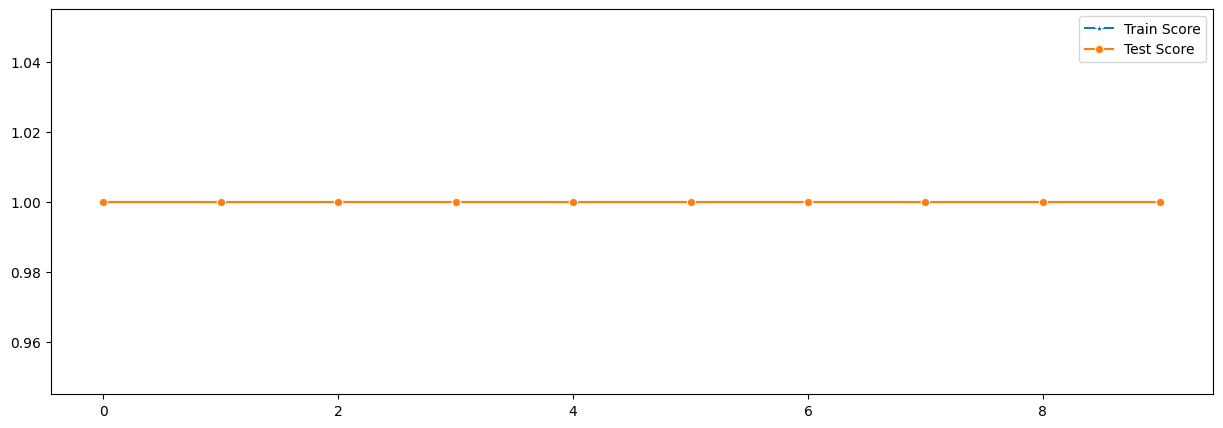

In [85]:
# In this chapter, I want to find the best random_state value.
test_score_list = []
train_score_list = []

for i in range(0,10):
    rfc2 = RandomForestClassifier(random_state=i)
    rfc2.fit(x_train, y_train)
    test_score_list.append(rfc2.score(x_test, y_test))
    train_score_list.append(rfc2.score(x_train, y_train))

plt.figure(figsize=(15,5))
p = sns.lineplot(x=range(0,10),y=train_score_list,marker='*',label='Train Score')
p = sns.lineplot(x=range(0,10),y=test_score_list,marker='o',label='Test Score')

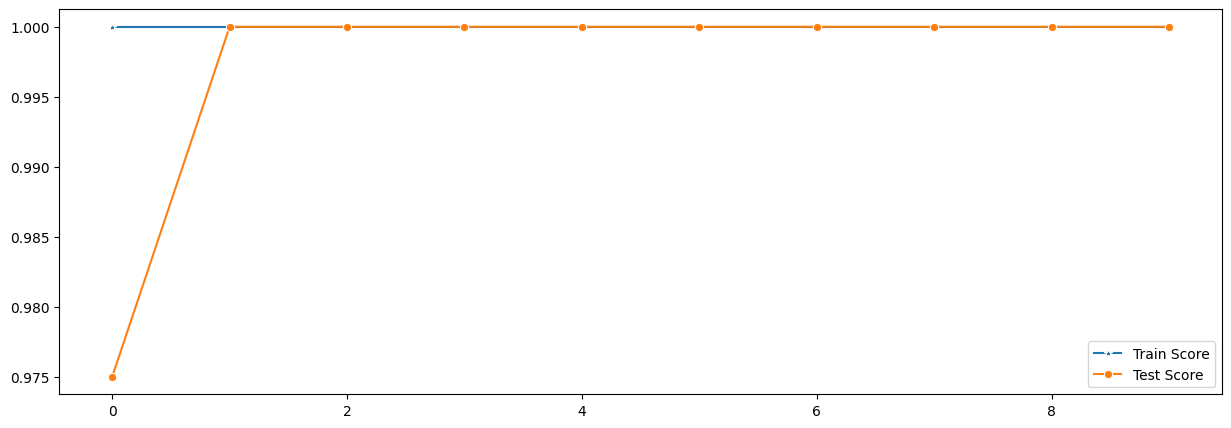

In [87]:
# I found the best random_stete value is five. Now I will find the best n_estimators parameter.
test_score_list = []
train_score_list = []

list_n_estimators = [10,20,30,40,50,60,70,80,90,100]


for i in range(0,len(list_n_estimators)):
    rfc3 = RandomForestClassifier(n_estimators=list_n_estimators[i], random_state=5)
    rfc3.fit(x_train, y_train)
    test_score_list.append(rfc3.score(x_test, y_test))
    train_score_list.append(rfc3.score(x_train, y_train))

plt.figure(figsize=(15,5))
p = sns.lineplot(x=range(0,len(list_n_estimators)),y=train_score_list,marker='*',label='Train Score')
p = sns.lineplot(x=range(0,len(list_n_estimators)),y=test_score_list,marker='o',label='Test Score')

### Random Forest Classifier With The Best Parameters

In [88]:
last_rfc = RandomForestClassifier(n_estimators=100, random_state=5)

# fit the model
last_rfc.fit(x_train,y_train)

predict = last_rfc.predict(x_test)

print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 1.0


In [89]:
y_pred_en = last_rfc.predict(x_test)

In [90]:
print('Model accuracy score with best parameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with best parameters: 1.0000


In [91]:
y_pred_train_en = last_rfc.predict(x_train)

y_pred_train_en

array([3, 3, 3, 4, 4, 1, 4, 4, 4, 3, 3, 4, 3, 4, 3, 4, 2, 4, 4, 4, 2, 4,
       0, 4, 3, 4, 4, 4, 4, 0, 3, 3, 3, 0, 2, 3, 4, 3, 2, 3, 1, 4, 2, 2,
       2, 0, 0, 2, 4, 2, 4, 4, 2, 4, 4, 4, 3, 4, 3, 4, 4, 3, 0, 3, 4, 2,
       1, 4, 3, 3, 4, 4, 3, 3, 0, 4, 0, 3, 4, 4, 4, 0, 1, 2, 4, 4, 4, 2,
       3, 3, 4, 1, 4, 4, 3, 0, 3, 3, 4, 4, 4, 4, 4, 4, 0, 3, 1, 2, 4, 2,
       2, 3, 4, 4, 4, 4, 3, 4, 2, 3, 4, 4, 3, 4, 3, 0, 4, 4, 1, 3, 4, 4,
       4, 4, 3, 4, 3, 3, 4, 1, 1, 4, 1, 4, 0, 3, 4, 3, 4, 4, 4, 3, 4, 4,
       4, 3, 3, 4, 4, 1])

In [92]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 1.0000


In [93]:
# print the scores with best parameters on training and test set

print('Training set score: {:.4f}'.format(last_rfc.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(last_rfc.score(x_test, y_test)))

Training set score: 1.0000
Test set score: 1.0000


## Evaluation Classification Models

#### Confusion Matrix For DecisionTreeClassifier Without Parameters

In [94]:
# For Desicion Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

cm_des = DecisionTreeClassifier()

# fit the model
cm_des.fit(x_train,y_train)

y_pred_cm = cm_des.predict(x_test)
y_true = y_test

cm_des1 = confusion_matrix( y_true, y_pred_cm)
cm_des1

array([[ 3,  0,  0,  0,  0],
       [ 0,  5,  0,  0,  0],
       [ 0,  0,  6,  0,  0],
       [ 0,  0,  0, 11,  0],
       [ 0,  0,  0,  0, 15]])

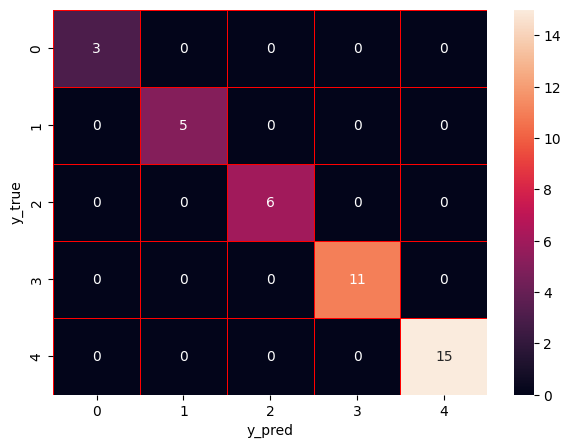

In [95]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des1, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

#### Confusion Matrix For Decision Tree Classifier With "gini"

In [96]:
cm_des_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

# fit the model
cm_des_gini.fit(x_train,y_train)

y_pred_cm = cm_des_gini.predict(x_test)
y_true = y_test

cm_des2 = confusion_matrix( y_true, y_pred_cm)
cm_des2

array([[ 3,  0,  0,  0,  0],
       [ 0,  0,  0,  5,  0],
       [ 0,  0,  6,  0,  0],
       [ 0,  0,  0, 11,  0],
       [ 0,  0,  0,  0, 15]])

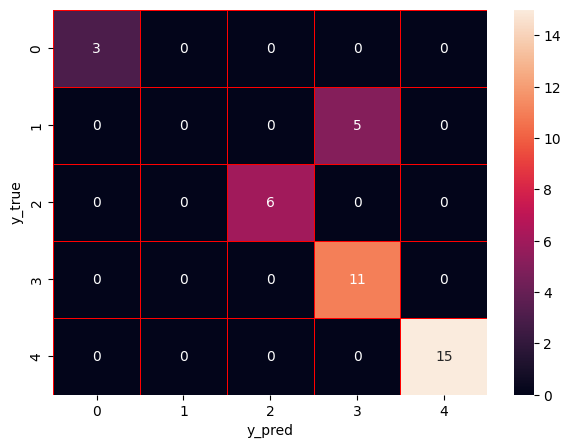

In [97]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des2, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

#### Confusion Matrix For Random Forest Classifier With The Best Parameters

In [98]:
cm_last_rfc = RandomForestClassifier(n_estimators=100, random_state=5)

# Fit The Model
cm_last_rfc.fit(x_train, y_train)

y_pred_cm = cm_last_rfc.predict(x_test)
y_true = y_test

cm_rfc = confusion_matrix(y_true, y_pred_cm)
cm_rfc

array([[ 3,  0,  0,  0,  0],
       [ 0,  5,  0,  0,  0],
       [ 0,  0,  6,  0,  0],
       [ 0,  0,  0, 11,  0],
       [ 0,  0,  0,  0, 15]])

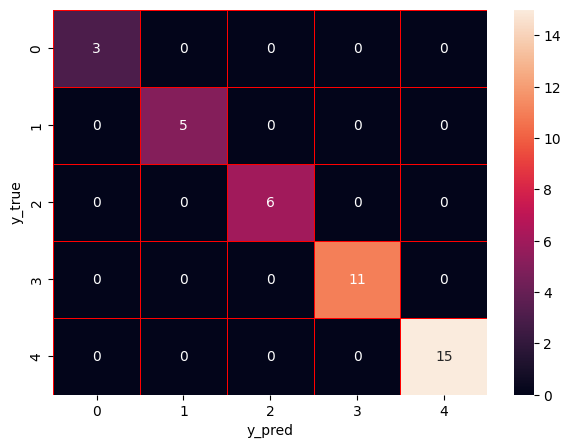

In [99]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_rfc, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()